In [3]:
!pip install neurokit2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 29.6 MB/s eta 0:00:00


In [4]:
!pip install wfdb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neurokit2 0.2.13 requires pandas<3.0.0, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3

In [5]:
import wfdb
import matplotlib.pyplot as plt
import neurokit2 as nk
import pandas as pd
import numpy as np

In [8]:
record = wfdb.rdrecord('100',
    pn_dir='mitdb')

In [9]:
ecg = record.p_signal[:,0]

In [10]:
sampling_rate = record.fs

In [11]:
time = np.arange(len(ecg))/sampling_rate

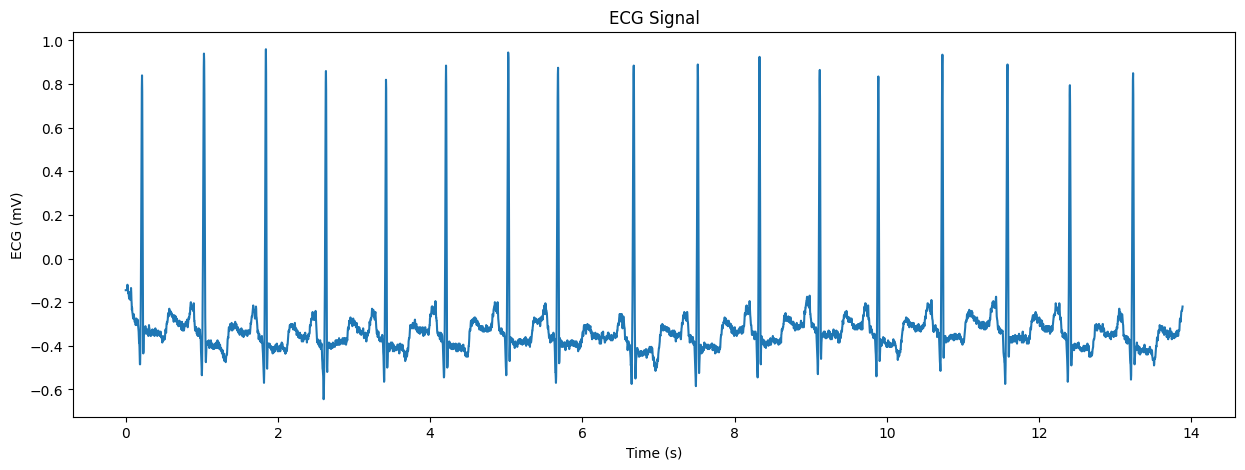

In [12]:
plt.figure(figsize = (15,5))
plt.plot(time[:5000], ecg[:5000])
plt.xlabel('Time (s)')
plt.ylabel('ECG (mV)')
plt.title('ECG Signal')
plt.show()

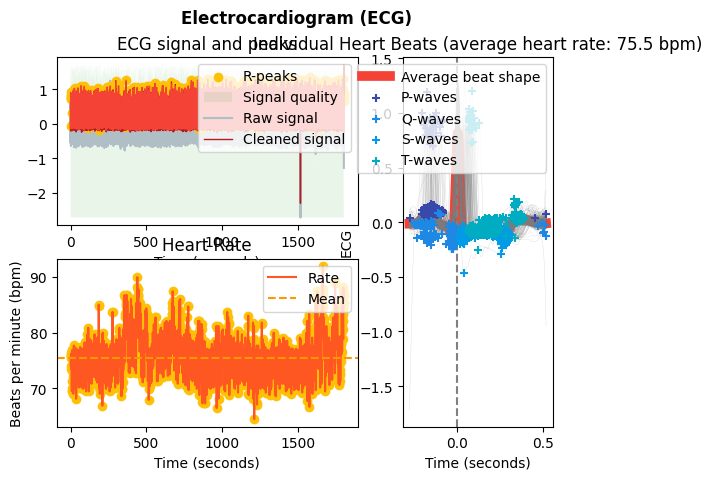

In [13]:
signals, info = nk.ecg_process(ecg, sampling_rate = sampling_rate)
nk.ecg_plot(signals, info)


In [14]:
BPM = signals["ECG_Rate"].mean()
print(BPM)

75.52396958351022


In [15]:
record.comments

['69 M 1085 1629 x1', 'Aldomet, Inderal']

In [16]:
r_peaks = info["ECG_R_Peaks"]
print(r_peaks)

[   370    662    946 ... 649231 649484 649733]


In [17]:
rr_intervals = np.diff(info["ECG_R_Peaks"]) / 500
print(rr_intervals)

[0.584 0.568 0.57  ... 0.506 0.506 0.498]


In [18]:
r_amplitudes = ecg[r_peaks]
print(r_amplitudes)

[0.94  0.885 0.81  ... 0.84  0.89  0.83 ]


In [19]:
print("Mean RR:", np.mean(rr_intervals))
print("RR Variability:", np.std(rr_intervals))

print("Mean R Amplitude:", np.mean(r_amplitudes))

Mean RR: 0.5721259911894273
RR Variability: 0.027153860569748292
Mean R Amplitude: 0.8977829150154117


In [20]:
records = [
    '100', '101', '103', '111', '112',
    '113', '115', '117', '121', '122']

In [21]:
results = []
for r in records:
  record = wfdb.rdrecord(r, pn_dir = 'mitdb')
  ecg = record.p_signal[:,0]
  sampling_rate = record.fs
  signals, info = nk.ecg_process(ecg, sampling_rate = sampling_rate)
  bpm = signals["ECG_Rate"].mean()
  r_peaks = info["ECG_R_Peaks"]
  rr_intervals = np.diff(r_peaks) / sampling_rate
  mean_rr = np.mean(rr_intervals)
  rr_var = np.std(rr_intervals)
  r_amplitudes = ecg[r_peaks]
  mean_r_amp = np.mean(r_amplitudes)
  comments = record.comments
  gender = comments[0].split()[1]
  results.append({
  "Record": r,
  "Gender": gender,
  "BPM": bpm,
  "Mean RR": mean_rr,
  "RR Variability": rr_var,
  "Mean R Amplitude": mean_r_amp})


In [22]:
df = pd.DataFrame(results)
print(df)

  Record Gender         BPM   Mean RR  RR Variability  Mean R Amplitude
0    100      M   75.523970  0.794619        0.037714          0.897783
1    101      F   62.015174  0.967684        0.066349          1.361555
2    103      M   69.271755  0.866285        0.045933          1.716233
3    111      F   70.614138  0.849853        0.037262          0.613524
4    112      M   84.375929  0.711145        0.020726         -0.037741
5    113      F  103.502597  0.603808        0.252856          0.888740
6    115      F   64.926144  0.924683        0.086340          1.633262
7    117      M   51.000986  1.176553        0.041940         -0.154472
8    121      F   61.905482  0.969258        0.082120          0.021495
9    122      M   82.272851  0.729341        0.040043          0.811465


In [27]:
comparison = df.groupby("Gender").mean(numeric_only=True)

print(comparison)

              BPM   Mean RR  RR Variability  Mean R Amplitude
Gender                                                       
F       72.592707  0.863057        0.104985          0.903715
M       72.489098  0.855589        0.037271          0.646654


In [29]:
import plotly.express as px

In [30]:
fig = px.bar(
    comparison.reset_index(),
    x="Gender",
    y="RR Variability",
    color="Gender",
    title="RR Variability by Gender"
)

fig.show()

In [31]:
fig = px.scatter(
    df,
    x="BPM",
    y="RR Variability",
    color="Gender",
    hover_data=["Record"],
    title="BPM vs RR Variability"
)

fig.show()

In [34]:
fig = px.bar(
    comparison.reset_index(),
    x="Gender",
    y="Mean R Amplitude",
    color="Gender",
    title="Mean R Amplitude by Gender"
)

fig.show()

In [33]:
fig = px.scatter(
    df,
    x="BPM",
    y="Mean R Amplitude",
    color="Gender",
    hover_data=["Record"],
    title="BPM vs Mean R Amplitude"
)

fig.show()